# Analyzing and Predicting Public Support for Title IX

## Introduction

Title IX is a federal civil rights law that was passed in 1972 that prohibits sex discrimination in educational programs and activities receiving federal financial assistance. Over the past five decades, Title IX has become particularly influential in expanding opportunities for women in athletics and strengthening protections against sex discrimination in educational institutions. Despite its importance, support for Title IX varies across different demographic and political groups. As debates surrounding fairness, gender equity, and women's sports gain national attention, universities are facing more public pressure to demonstrate their commitment to gender equity. Understanding how different groups perceive Title IX has become a practical challenge for institutions that want to uphold and strengthen the protections of Title IX. That is why our research lab has been awarded a grant, so that we can help universities evaluate how the public views Title IX and to develop strategies for increasing awareness and support for these protections.

Previous research provides important context for these differences. A 2022 Pew Research Center survey found that 63% of Americans familiar with Title IX believed it had a positive impact on gender equality, but attitudes differed considerably across political groups. Democrats were substantially more likely than Republicans to view the law's impact positively. The survey also found gender differences in attitudes toward equality in college athletics, including greater support among women for equal funding between men's and women's sports (Igielnik, 2022). Research focused specifically on college athletes has similarly found differences in how people view gender-equity policies. Druckman, Rothschild, and Sharrow (2018) found broad support for gender equity among college athletes, but also found that attitudes toward Title IX were particularly significant among women and individuals who perceived continuing sex discrimination. Other research has demonstrated that gender and attitudes toward equality can shape support for maintaining Title IX protections in college sports (Druckman et al., 2020).

Building on this research, our analysis uses a national survey collected by the Marist Center for Sports Communication to examine which individuals are most likely to support Title IX and its protections. The dataset contains demographic, political, and sports-related variables that allow us to investigate patterns in public support. Rather than making a causal claim, this report focuses on identifying relationships that may be useful for policy and outreach decisions. In particular, the analysis examines gender, political affiliation, and sports engagement because prior research suggests that demographic identity, political beliefs, and relationships to athletics can influence attitudes toward gender equity and Title IX. By identifying groups that are more or less likely to support Title IX, this report aims to provide universities with evidence that can inform more targeted education and outreach efforts.

## Data Description & Descriptive Statistics

The data used in this report come from a national survey conducted by the Marist Center for Sports Communication in June 2022. The dataset, provided in the file, marist_sports_final_3.csv, contains responses from 573 adult respondents and includes demographic, political, and sports-related variables. The survey was designed to measure public attitudes toward sports, gender equity, and related policies, which makes it well suited for analyzing support for Title IX and its protections in the United States.

The primary outcome variable for this analysis is title_ix_iot, which measures whether respondents hold favorable or unfavorable views of Title IX protections in sports. To better study patterns of support, this variable is recoded into a binary indicator that represents whether a respondent supports Title IX or not. The key explanatory variables in this analysis are **sex** (male, female, non-binary), **political affiliation** (Democrat, Republican, Independent), and **sports engagement** (whether individuals identify as a sports fan). These variables were selected because prior theories about policy suggest that attitudes toward gender-equity policies are shaped by demographic identity, political ideology, and personal connections to a topic. Other variables in the dataset that don't have a clear conceptual link to Title IX support are not emphasized as much in this report.

This section shows summaries and visualizations that describe the overall support for Title IX and explores how support varies across key demographic and sports-related groups. These descriptive statistics help answer the question of who currently supports Title IX and identify groups that may be priorities for targeted education and outreach.

In [1]:
import numpy as np # imports numpy into shorthand expression np
import datascience as ds # imports datascience into shorthand expression ds
import matplotlib

# Required to view plots in a notebook
%matplotlib inline

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [2]:
marist = ds.Table.read_table('marist_sports_final_3.csv')

In [3]:
def support_title_ix(x):
    return 1 if x == "Favorable" else 0
marist = marist.with_column("support_ix", marist.apply(support_title_ix, "title_ix_tot"))

In [4]:
overall = marist.group("support_ix")
overall

support_ix,count
0,250
1,323


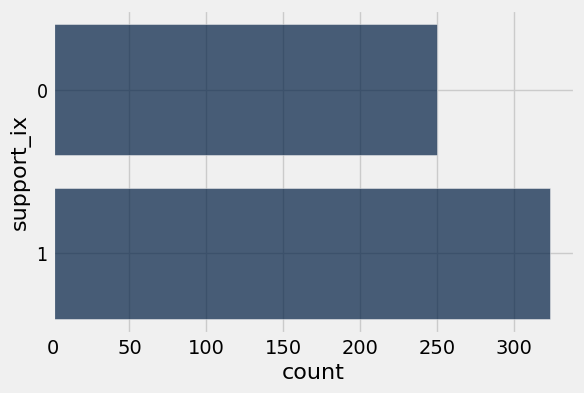

In [5]:
overall.barh("support_ix", "count")

The table and bar chart show that a majority of respondents express favorable views of Title IX. Specifically, 323 out of 573 respondents report support for Title IX, while the other 250 respondents don't support Title IX. This indicates that although support for Title IX is more common than unfavorable views for Title IX, a substantial portion of the population remains unsupportive of it, which highlights the importance of targeted education and outreach efforts.

In [6]:
sex_support = marist.select("sex", "support_ix").group("sex", np.mean)
sex_support

sex,support_ix mean
Female,0.508547
Male,0.604167
Non-binary,0.333333


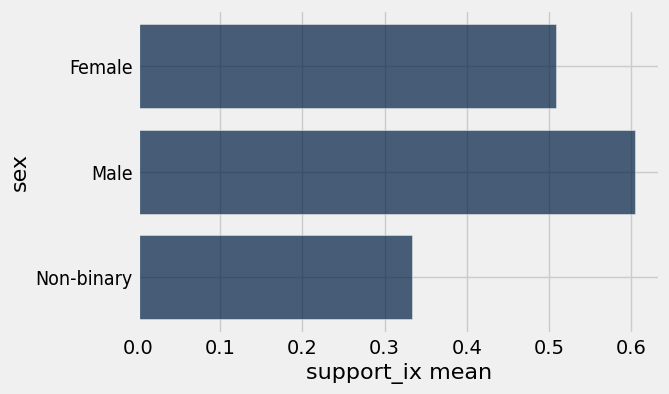

In [7]:
sex_support.barh("sex", "support_ix mean")

Support for Title IX varies across gender groups. The bar chart displays the proportion of respondents within each gender category who report favorable or unfavorable views for Title IX. In this sample, male respondents show the highest level of support, followed by female respondents, and support among non-binary respondents is lower. These descriptive statistics suggest that gender is associated with attitudes toward Title IX, though the smaller size of some gender groups (like the non-binary group) may require more cautious interpretation. These patterns motivate further inferential analysis to determine whether observed differences reflect meaningful population-level trends or not.

## Inference: Hypothesis Test or Confidence Interval

This section examines whether support for Title IX differs between men and women in the U.S. population. The outcome variable is **support_ix**, where a value of 1 indicates favorable support for Title IX, and 0 indicates unfavorable support. The parameter of interest in this section is the **difference in population proportions** that support Title IX, which is defined as the proportion of men who support Title IX minus the proportion of women who support Title IX. The null hypothesis states that there is no difference in support between men and women, and the alternative hypothesis states that there is a difference.

The research lab and I used a bootstrap confidence interval (CI) to estimate this difference because a bootstrap CI doesn't rely on strong distributional assumptions and is well suited for comparing proportions across groups using sample data. In the sample, the proportion of men who supported Title IX was approximately **9.6 percentage points higher** than the proportion of women who supported Title IX. By repeatedly resampling the data with replacement and recalculating this difference, a 95% bootstrap CI was constructed. The resulting interval was approximately **(0.016, 0.184)**, meaning the population difference in support could plausibly range from about **1.6 to 18.4 percentage points higher among men than women**. Because this interval doesn't include zero, the analysis provides evidence of a statistically significant difference in support for Title IX between men and women. Specifically, the positive interval indicates that **men are more likely than women to express favorable views of Title IX** in this sample. This finding suggests that gender is associated with attitudes toward Title IX and motivates further analysis of demographic and political characteristics that may help identify groups for targeted education and outreach efforts.

**Null Hypothesis (H₀)**: There is no difference in the proportion of men and women who support Title IX.

**Alternative Hypothesis (Hₐ)**: There is a difference in the proportion of men and women who support Title IX.

In [8]:
# Split dataset into men and women groups

men = marist.where("sex", "Male")
women = marist.where("sex", "Female")

In [9]:
# Compute observed proportion supporting Title IX in each group
# support_ix coded: 1 = favorable support, 0 = unfavorable

p_men = np.mean(men.column("support_ix"))
p_women = np.mean(women.column("support_ix"))

In [10]:
# Observed difference in support for Title IX by sex
# Observed difference = proportion of men who support - proportion of women who support

observed_diff = p_men - p_women
observed_diff

0.095619658119658113

In [11]:
# Create function that computes difference in support for any given sample

def diff_in_support(sample):
    men_sample = sample.where("sex", "Male")
    women_sample = sample.where("sex", "Female")
    return np.mean(men_sample.column("support_ix")) - np.mean(women_sample.column("support_ix"))

In [12]:
# Run bootstrap (creates resamples and computes the statistic each time)

bootstrap_diffs = ds.make_array()

for i in range(1000):
    resample = marist.sample(with_replacement = True)
    bootstrap_diffs = np.append(bootstrap_diffs, diff_in_support(resample))

bootstrap_diffs

array([  7.60241204e-02,   1.40647848e-01,   1.07744539e-01,
         1.05270737e-01,   9.89927478e-02,   8.51195863e-02,
         1.24670719e-01,   9.68692691e-02,   1.05755987e-01,
         1.32870662e-02,   6.92513369e-02,   8.85112062e-02,
         1.00329113e-01,   9.78515073e-02,   1.40372561e-01,
         8.54720706e-02,   5.11420683e-02,  -1.32286651e-02,
         9.81720295e-02,   1.67574361e-01,   1.31271382e-01,
         1.23954600e-01,   1.95721711e-01,   1.18226042e-01,
         7.00166706e-02,   2.28785512e-01,   1.28654971e-01,
         1.73787714e-01,   1.05519481e-01,   1.01140609e-01,
         1.11253197e-02,   9.89703774e-02,   1.44377136e-01,
         7.99618927e-02,   1.73998936e-01,   1.15308303e-01,
         8.03210837e-02,   1.30403242e-01,   1.06683497e-01,
         9.45717131e-02,   3.00423953e-02,   1.69132347e-01,
         1.40082776e-01,   9.60426005e-02,   8.58438614e-02,
         1.18147657e-01,   3.04834484e-02,   9.45311703e-02,
         7.68998186e-02,

In [13]:
# 95% Bootstrap Confidence Interval
# Use 2.5th and 97.5th percentiles of bootstrap distribution

left = np.percentile(bootstrap_diffs, 2.5)
right = np.percentile(bootstrap_diffs, 97.5)

left, right

(0.016167698812982419, 0.18423773550134342)

## Prediction

The goal of this section is to identify which individuals are most likely to support Title IX and its protections, which can help our university research lab provide information that universities can use to better target education and outreach efforts toward groups that may be less supportive. The outcome variable for this analysis is support for Title IX, with the positive case coded as support_ix = 1, indicating a favorable view of Title IX. The predictor variables are coded as dummy (binary) variables for **political affiliation (Democrat, Independent, Republican)**, **gender (Female, Male)**, **sports fandom**, and **parental status**. These predictor variables were selected for this report because they capture key demographic, political, and behavioral characteristics that may be related to attitudes toward gender equity in sports.

To build the prediction model, the dataset was split into an 80% training set and a 20% testing set. A K-Nearest Neighbors (KNN) classifier was used, and multiple models were evaluated by varying the number of neighbors (*k* = 5, 9, 15, 19, 25) and the probability threshold used to classify a respondent as supportive (0.1, 0.3, 0.5, 0.7, 0.9). Rather than evaluating the models using accuracy alone, model performance was compared using **accuracy**, **precision**, **recall**, and **F1 score**. Accuracy measures the overall roportal of correct predictions, precision measures how often respondents predicted to support Title IX actually support it, and recall measures how effectively the model identifies respondents who actually support Title IX. The F1 score summarizes the balance between precision and recall, providing an additional measure of how well the model performs across both. Evaluating all three metrics provides a more complete assessment of model performance and allows the final model to be selected based on both its predictive performance and the analytical objective of this report.

In [14]:
# Creating dummy variables

# Political affiliation dummies
democrat = marist.column("political_affiliation") == "Democrat"
independent = marist.column("political_affiliation") == "Independent"
republican = marist.column("political_affiliation") == "Republican"

# Sex dummies
female = marist.column("sex") == "Female"
male = marist.column("sex") == "Male"

# Sports fan dummy
sportsfan = marist.column("sports_fan") == "Yes"

# Parental status dummy
has_kids = marist.column("has_children") == "Yes"

# Drop original categorical variables
marist_clean = marist.with_columns("Democrat", democrat, "Independent", independent, "Republican", republican, "Female", female, "Male", male, "Sportsfan", sportsfan, "Has_kids", has_kids).drop("political_affiliation").drop("has_children").drop("sex").drop("sports_fan").drop("title_ix_tot")
marist_clean.show(5)

birth_year,race,ethnicity,education_level,presidential_vote,residential_location,womens_sports_growth,support_ix,Democrat,Independent,Republican,Female,Male,Sportsfan,Has_kids
1960,White or Caucasian,Not Latino or Hispanic,HIGH SCHOOL GRADUATE/HIGH SCHOOL DIPLOMA OR EQUIVALENT ( ...,Donald Trump,Rural,"A major factor, but not the main factor",1,False,True,False,False,True,True,False
1955,White or Caucasian,Not Latino or Hispanic,BACHELORS DEGREE (BA-BS-4 YEARS OF COLLEGE),Joe Biden,A small town,"A major factor, but not the main factor",1,True,False,False,False,True,True,False
1957,White or Caucasian,Not Latino or Hispanic,MASTERS/GRADUATE/PhD/PROFESSIONAL DEGREE (MA-MS-JD),Donald Trump,A big city,"A major factor, but not the main factor",1,False,True,False,False,True,True,False
1944,White or Caucasian,Not Latino or Hispanic,MASTERS/GRADUATE/PhD/PROFESSIONAL DEGREE (MA-MS-JD),Joe Biden,A small city,"A major factor, but not the main factor",1,True,False,False,True,False,False,False
1951,White or Caucasian,Not Latino or Hispanic,MASTERS/GRADUATE/PhD/PROFESSIONAL DEGREE (MA-MS-JD),Joe Biden,Suburban,"A major factor, but not the main factor",0,False,True,False,False,True,False,False


In [15]:
# Keep only the dummy predictor columns and outcome

marist_model = marist_clean.select("Democrat", "Independent", "Republican", "Female", "Male", "Sportsfan", "Has_kids", "support_ix")

In [16]:
# Train/test split

rows_to_take = int(marist_clean.num_rows * 0.8)

# Shuffle rows before splitting

shuffled = marist_model.sample(with_replacement = False)

train = shuffled.take(np.arange(rows_to_take))
test = shuffled.take(np.arange(rows_to_take, marist_model.num_rows))

train.num_rows, test.num_rows

(458, 115)

In [17]:
# Define predictors and outcome
# Outcome: support for Title IX (1 = favorable, 0 = unfavorable)
# Predictors: demographic and behavioral dummy variables

predictors = train.drop("support_ix").rows
outcome = train.column("support_ix")

test_predictors = test.drop("support_ix").rows
test_outcome = test.column("support_ix")

In [18]:
# Evaluate KNN models across multiple values of k and classification thresholds to identify the best performing model

# Values of k (number of neighbors) to test
k_values = ds.make_array(5, 9, 15, 19, 25)

# Thresholds for converting predicted probabilities into class labels
threshold_values = ds.make_array(0.1, 0.3, 0.5, 0.7, 0.9)

# Create arrays to store results
k_col = ds.make_array()
threshold_col = ds.make_array()
accuracy_col = ds.make_array()
precision_col = ds.make_array()
recall_col = ds.make_array()
f1_col = ds.make_array()

# Loop over different k values
for k in k_values:
    
    # Fit KNN model
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(predictors, outcome)
    
    # Get predicted probabilities for the positive case (support_ix = 1)
    probs = knn.predict_proba(test_predictors)[:, 1]
    
    # Loop over classification thresholds
    for threshold in threshold_values:
        
        # Convert probabilities into predicted classes
        predictions = probs >= threshold
        
        # Calculate evaluation metrics
        accuracy = accuracy_score(test_outcome, predictions)
        precision = precision_score(test_outcome, predictions, zero_division = 0)
        recall = recall_score(test_outcome, predictions, zero_division = 0)
        f1 = f1_score(test_outcome, predictions, zero_division = 0)
        
        # Store results
        k_col = np.append(k_col, k)
        threshold_col = np.append(threshold_col, threshold)
        accuracy_col = np.append(accuracy_col, accuracy)
        precision_col = np.append(precision_col, precision)
        recall_col = np.append(recall_col, recall)
        f1_col = np.append(f1_col, f1)
        
# Create results table
knn_results = ds.Table().with_columns(
    "k", k_col,
    "threshold", threshold_col,
    "accuracy", accuracy_col,
    "precision", precision_col,
    "recall", recall_col,
    "f1", f1_col
)

# Display all model results
knn_results.show()

k,threshold,accuracy,precision,recall,f1
5,0.1,0.53913,0.535088,1,0.697143
5,0.3,0.547826,0.548387,0.836066,0.662338
5,0.5,0.626087,0.645161,0.655738,0.650407
5,0.7,0.6,0.647059,0.540984,0.589286
5,0.9,0.53913,0.653846,0.278689,0.390805
9,0.1,0.530435,0.530435,1,0.693182
9,0.3,0.582609,0.565657,0.918033,0.7
9,0.5,0.66087,0.666667,0.721311,0.692913
9,0.7,0.556522,0.678571,0.311475,0.426966
9,0.9,0.469565,0,0,0


In [19]:
# Confusion matrix for the selected KNN model

final_knn = KNeighborsClassifier(n_neighbors = 9)
final_knn.fit(predictors, outcome)

final_probs = final_knn.predict_proba(test_predictors)[:, 1]

final_predictions = final_probs >= 0.5

confusion_matrix(test_outcome, final_predictions)

array([[32, 22],
       [17, 44]])

Based on the performance of the models across accuracy, precision, and recall, the KNN model with **k = 9** and a classification threshold of **0.5** was selected as the final predictive model. This model achieved an accuracy of approximately **66.1%**, a precision of **66.7%**, a recall of **72.1%**, and an F1 score of **69.3%**. Although some models achieved higher values on individual metrics, those improvements came with substantial tradeoffs in other measures. Models with lower classification thresholds achieved very high recall but lower precision and accuracy, while models with higher thresholds achieved greater precision but failed to identify many respondents who actually supported Title IX. The selected model provides a more balanced performance across these measures, making it more useful for distinguishing between individuals who are more and less likely to support Title IX.

The confusion matrix provides additional information about the model's performance. Of the 115 respondents in the test set, the model correctly classified 32 respondents who did not support Title IX and 44 respondents who did support Title IX. It incorrectly classified 22 non-supporters as supporters and 17 supporters as non-supporters. These results show that the model is more successful at identifying supporters than non-supporters, which is also reflected in its recall of approximately 72.1%. Because the broader objective of this analysis is to inform targeted outreach toward groups that may be less supportive of Title IX, this limitation is important to consider when interpreting the model's predictions.

## Conclusion

This report provides practical insight into how universities can better understand public attitudes toward Title IX and gender equity. The findings show that support for Title IX is **not evenly distributed across respondents**, with meaningful differences associated with **gender**, **political affiliation**, and **engagement with sports**. In particular, the analysis found lower levels of support for **women**, **individuals who are not sports fans**, and **Republicans and Independents**. The gender difference was also supported by the bootstrap analysis, which estimated that men's support was approximately **9.6 percentage points higher than women's**, with a 95% confidence interval ranging from approximately **1.6 to 18.4 percentage points**. These findings suggest that universities should not assume that different groups understand or view Title IX and its protections in the same way. Instead, recognizing differences in public attitudes can help institutions develop more informed approaches to Title IX education and communication.

The predictive analysis further demonstrates both the potential and limitations of using demographic and behavioral characteristics to identify patterns in Title IX support. The selected KNN model achieved **66.1% accuracy**, **66.7% precision**, **72.1% recall**, and a **69.3% F1 score**, providing a reasonable balance across multiple measures of predictive performance. However, the confusion matrix showed that the model was better at identifying supporters than non-supporters, meaning its predictions should be interpreted cautiously and used alongside the broader descriptive and statistical findings rather than as a definitive method for identifying individual attitudes.

Based on the overall findings, universities may benefit from **targeted outreach and education efforts** rather than relying only on broad, generalized messaging about Title IX. Groups associated with lower levels of support in this analysis could be important audiences for education efforts that explain the purpose, protections, and broader impact of Title IX. At the same time, these relationships should not be interpreted as causal or as evidence that every individual within these groups holds the same views. Overall, this analysis demonstrates how survey data and predictive modeling can help universities better understand patterns in public opinion and develop more evidence-based approaches to communicating about Title IX and gender equity.

## References

Druckman, J. N., Rothschild, J. E., & Sharrow, E. A. (2018). Gender policy feedback: Perceptions of sex equity, Title IX, and political mobilization among college athletes. *Political Research Quarterly, 71*(3), 642-653.

Druckman, J. N., Rothschild, J. E., & Sharrow, E. A. (2020). Public opinion, crisis, and vulnerable populations: The case of Title IX and COVID-19. *Politics & Gender.*

Igielnik, R. (2022). Most Americans who are familiar with Title IX say it's had a positive impact on gender equality. *Pew Research Center.*